# I-JEPA Analysis

Analysis of I-JEPA (Image-based Joint-Embedding Predictive Architecture) pretrained on STL-10 (96x96 images).
I-JEPA is ViT-based, predicts representations (not pixels) of masked target blocks using context patches.

**Sections:**
- **A. Training Trajectories** -- loss, k-NN accuracy, and learning rate over epochs
- **B. Evaluation Results** -- k-NN sweep and linear probe across all checkpoints
- **C. Attention Map Visualization** -- per-head attention from the ViT context encoder
- **D. Target Block Masking Visualization** -- context vs target regions and predicted representations

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from models.ijepa import IJEPA
from evaluation import extract_features
from evaluation.knn import knn_classify
from evaluation.linear_probe import LinearProbe
from utils.data import get_eval_loaders, STL10_MEAN, STL10_STD

sns.set_theme(style="whitegrid", font_scale=1.1)
device = "cuda" if torch.cuda.is_available() else "cpu"
CLASS_NAMES = ["airplane", "bird", "car", "cat", "deer", "dog", "horse", "monkey", "ship", "truck"]
RESULTS_DIR = PROJECT_ROOT / "results" / "ijepa"

print(f"Device: {device}")
print(f"Results dir: {RESULTS_DIR}")

Device: cuda
Results dir: /home/justinas/ssl_image_method_comparison/results/ijepa


## A. Training Trajectories

In [2]:
history_path = RESULTS_DIR / "history.json"
if history_path.exists():
    with open(history_path) as f:
        history = json.load(f)

    epochs = [h["epoch"] for h in history]
    losses = [h["loss"] for h in history]
    knn_accs = [h["knn_top1"] for h in history]
    lrs = [h["lr"] for h in history]

    print(f"Training epochs: {len(history)}")
    print(f"Final loss: {losses[-1]:.4f}")
    print(f"Best k-NN accuracy: {max(knn_accs):.4f} (epoch {epochs[np.argmax(knn_accs)]})")
else:
    print("history.json not found -- training may still be in progress.")

Training epochs: 100
Final loss: 0.0001
Best k-NN accuracy: 0.6973 (epoch 289)


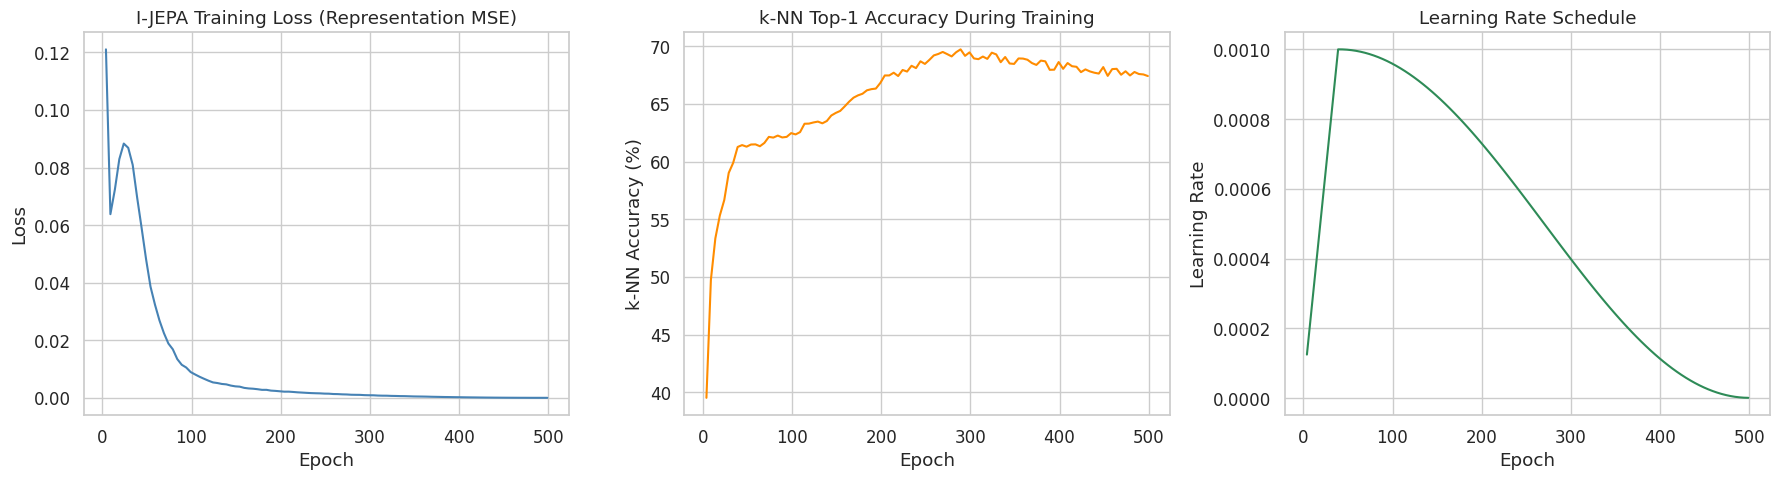

In [3]:
if history_path.exists():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(epochs, losses, color="steelblue")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("I-JEPA Training Loss (Representation MSE)")

    axes[1].plot(epochs, [a * 100 for a in knn_accs], color="darkorange")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("k-NN Accuracy (%)")
    axes[1].set_title("k-NN Top-1 Accuracy During Training")

    axes[2].plot(epochs, lrs, color="seagreen")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Learning Rate")
    axes[2].set_title("Learning Rate Schedule")

    plt.tight_layout()
    plt.show()

## B. Evaluation Results

Pre-computed linear probe and k-NN evaluation across all training checkpoints.

In [4]:
# Load pre-computed evaluation results across all checkpoints
all_eval_path = PROJECT_ROOT / "results" / "all_eval_results.json"
if all_eval_path.exists():
    with open(all_eval_path) as f:
        all_results = json.load(f)

    ijepa_results = sorted(
        [r for r in all_results if r["method"] == "ijepa" and r["checkpoint_name"].startswith("checkpoint_")],
        key=lambda r: r["epoch"],
    )
    if not ijepa_results:
        ijepa_results = sorted(
            [r for r in all_results if r["method"] == "ijepa"],
            key=lambda r: r["epoch"],
        )
    print(f"Loaded {len(ijepa_results)} checkpoint evaluations")
else:
    ijepa_results = []
    print("all_eval_results.json not found -- run scripts/evaluate_all.py first")

Loaded 10 checkpoint evaluations


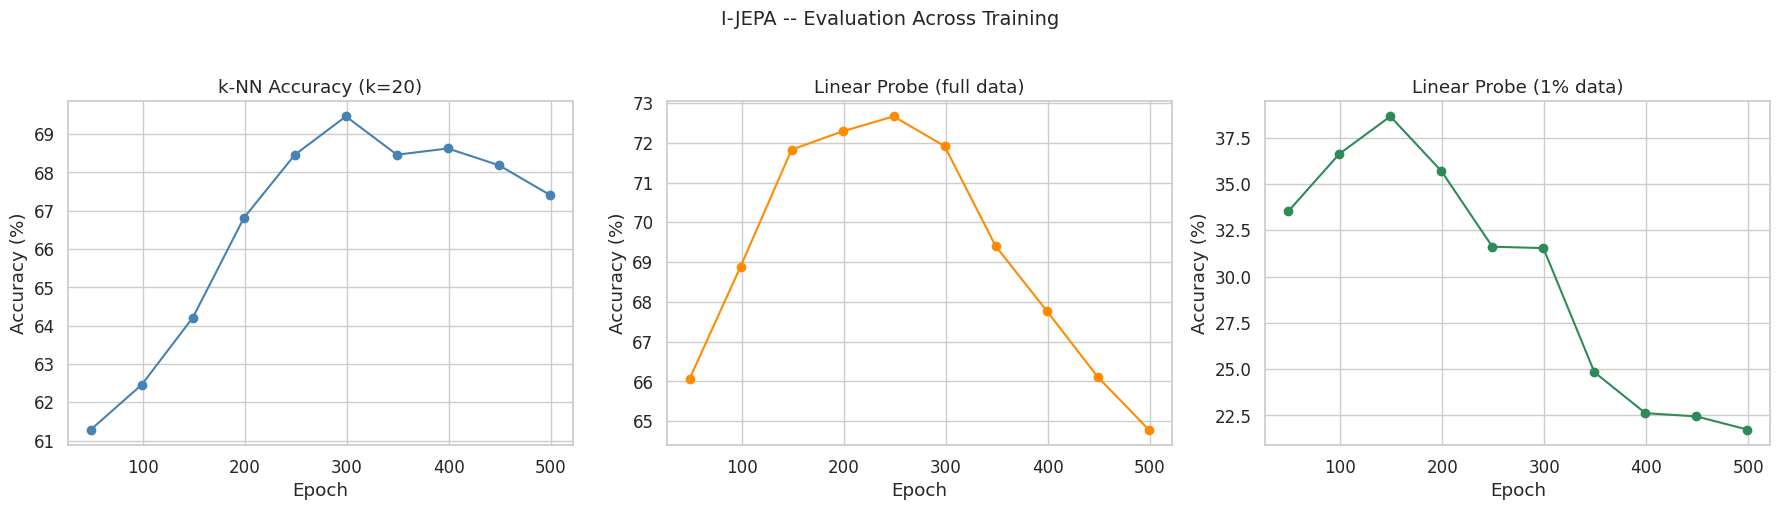

In [5]:
if ijepa_results:
    eval_epochs = [r["epoch"] for r in ijepa_results]
    eval_knn20 = [r["knn"]["20"] for r in ijepa_results]
    eval_probe = [r["linear_probe"] for r in ijepa_results]
    eval_probe_low = [r["linear_probe_lowdata"] for r in ijepa_results]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(eval_epochs, [a * 100 for a in eval_knn20], "o-", color="steelblue")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
    axes[0].set_title("k-NN Accuracy (k=20)")

    axes[1].plot(eval_epochs, [a * 100 for a in eval_probe], "o-", color="darkorange")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title("Linear Probe (full data)")

    axes[2].plot(eval_epochs, [a * 100 for a in eval_probe_low], "o-", color="seagreen")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy (%)")
    axes[2].set_title("Linear Probe (1% data)")

    fig.suptitle("I-JEPA -- Evaluation Across Training", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

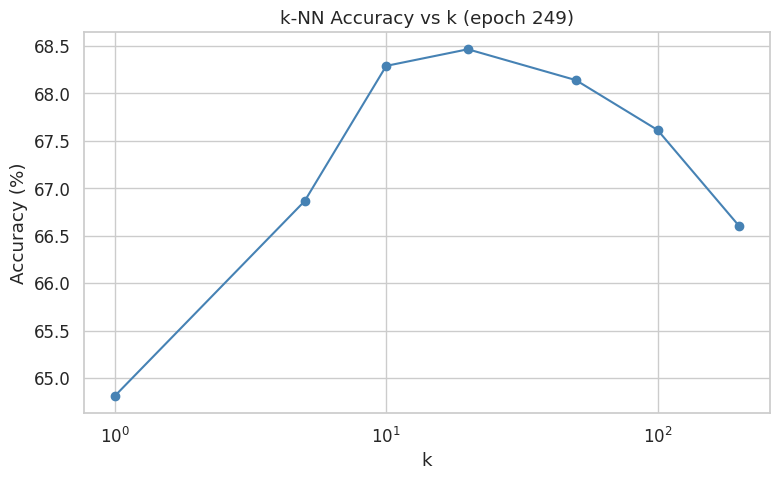

In [6]:
if ijepa_results:
    best_idx = int(np.argmax(eval_probe))
    best_result = ijepa_results[best_idx]
    best_knn = best_result["knn"]

    fig, ax = plt.subplots(figsize=(8, 5))
    k_vals = [int(k) for k in best_knn.keys()]
    accs = [best_knn[str(k)] * 100 for k in k_vals]
    ax.plot(k_vals, accs, "o-", color="steelblue")
    ax.set_xscale("log"); ax.set_xlabel("k"); ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"k-NN Accuracy vs k (epoch {best_result['epoch']})")
    plt.tight_layout()
    plt.show()

In [7]:
if ijepa_results:
    print(f"{'Checkpoint':<25s} {'Epoch':>6s} {'k-NN(20)':>10s} {'Probe':>10s} {'Probe(1%)':>10s}")
    print("-" * 63)
    for r in ijepa_results:
        marker = " <-- best" if r is best_result else ""
        print(f"{r['checkpoint_name']:<25s} {r['epoch']:>6d} "
              f"{r['knn']['20']*100:>9.2f}% {r['linear_probe']*100:>9.2f}% "
              f"{r['linear_probe_lowdata']*100:>9.2f}%{marker}")

Checkpoint                 Epoch   k-NN(20)      Probe  Probe(1%)
---------------------------------------------------------------
checkpoint_0049.pt            49     61.29%     66.06%     33.52%
checkpoint_0099.pt            99     62.46%     68.89%     36.62%
checkpoint_0149.pt           149     64.21%     71.83%     38.65%
checkpoint_0199.pt           199     66.81%     72.29%     35.70%
checkpoint_0249.pt           249     68.46%     72.66%     31.61% <-- best
checkpoint_0299.pt           299     69.46%     71.91%     31.54%
checkpoint_0349.pt           349     68.46%     69.40%     24.84%
checkpoint_0399.pt           399     68.62%     67.77%     22.62%
checkpoint_0449.pt           449     68.19%     66.11%     22.45%
checkpoint_0499.pt           499     67.41%     64.79%     21.74%


## C. Attention Map Visualization

The I-JEPA context encoder is a ViT with 6 TransformerBlocks (same architecture as MAE's encoder).
We monkey-patch selected blocks to capture per-head attention weights and visualize
how different heads attend from a center query patch across the 24x24 patch grid.

In [8]:
# Load model (best by linear probe if available, else best.pt) for visualization
if ijepa_results:
    best_ckpt_path = RESULTS_DIR / best_result["checkpoint_name"]
else:
    best_ckpt_path = RESULTS_DIR / "best.pt"

ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=True)
ckpt_args = ckpt["args"]
model = IJEPA(
    patch_size=ckpt_args.get("patch_size", 4),
    embed_dim=ckpt_args.get("encoder_dim", 384),
    encoder_depth=ckpt_args.get("encoder_depth", 6),
    encoder_heads=ckpt_args.get("encoder_heads", 6),
    pred_depth=ckpt_args.get("pred_depth", 4),
    pred_heads=ckpt_args.get("pred_heads", 6),
    momentum=ckpt_args.get("momentum", 0.996),
)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device).eval()

loaders = get_eval_loaders(batch_size=256)
print(f"Loaded I-JEPA from {best_ckpt_path.name}")

Loaded I-JEPA from checkpoint_0249.pt


In [9]:
attn_maps = {}


def patch_block(block, layer_idx):
    """Monkey-patch a TransformerBlock to capture attention weights."""
    original_forward = block.forward

    def new_forward(x):
        normed = block.norm1(x)
        attn_out, attn_weights = block.attn(
            normed, normed, normed,
            need_weights=True, average_attn_weights=False,
        )
        attn_maps[layer_idx] = attn_weights.detach().cpu()
        x = x + attn_out
        x = x + block.mlp(block.norm2(x))
        return x

    block.forward = new_forward
    return original_forward


# Patch blocks 0, 2, 5 (first, middle, last)
originals = {}
for i in [0, 2, 5]:
    originals[i] = patch_block(model.encoder.blocks[i], i)

# Run forward on a single image (full encoding, eval mode)
sample_img = next(iter(loaders["test"]))[0][:1].to(device)
with torch.no_grad():
    model.encoder(sample_img)

# Restore originals
for i, orig in originals.items():
    model.encoder.blocks[i].forward = orig

print(f"Captured attention maps for blocks: {sorted(attn_maps.keys())}")
for idx, attn in attn_maps.items():
    print(f"  Block {idx}: {tuple(attn.shape)}")

Captured attention maps for blocks: [0, 2, 5]
  Block 0: (1, 6, 576, 576)
  Block 2: (1, 6, 576, 576)
  Block 5: (1, 6, 576, 576)


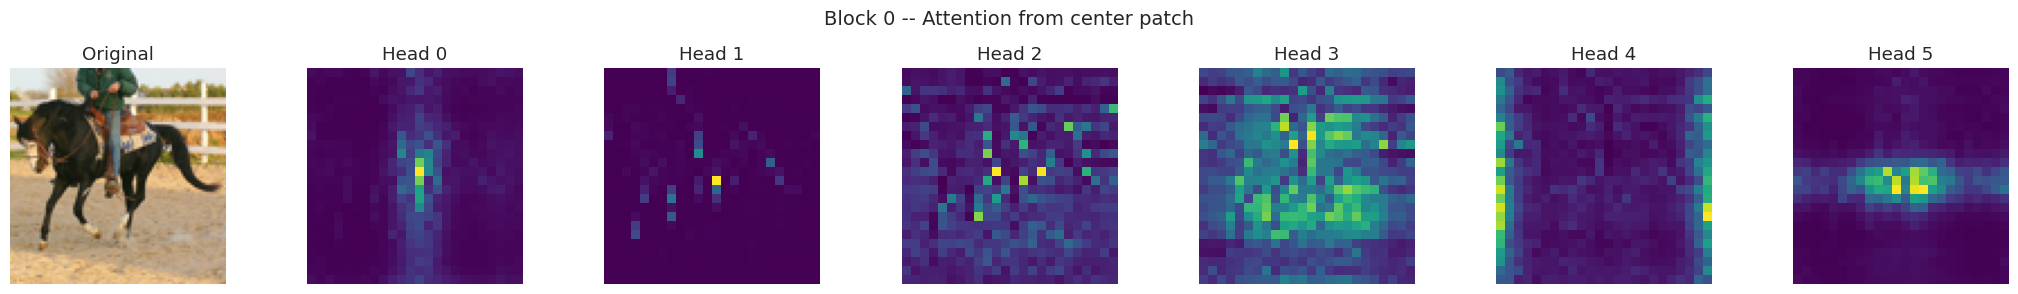

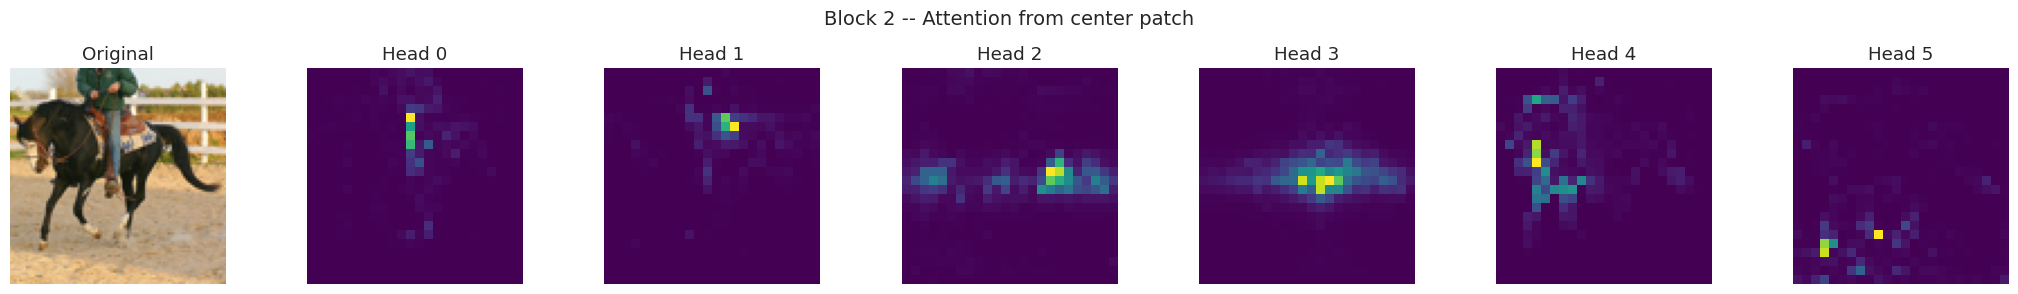

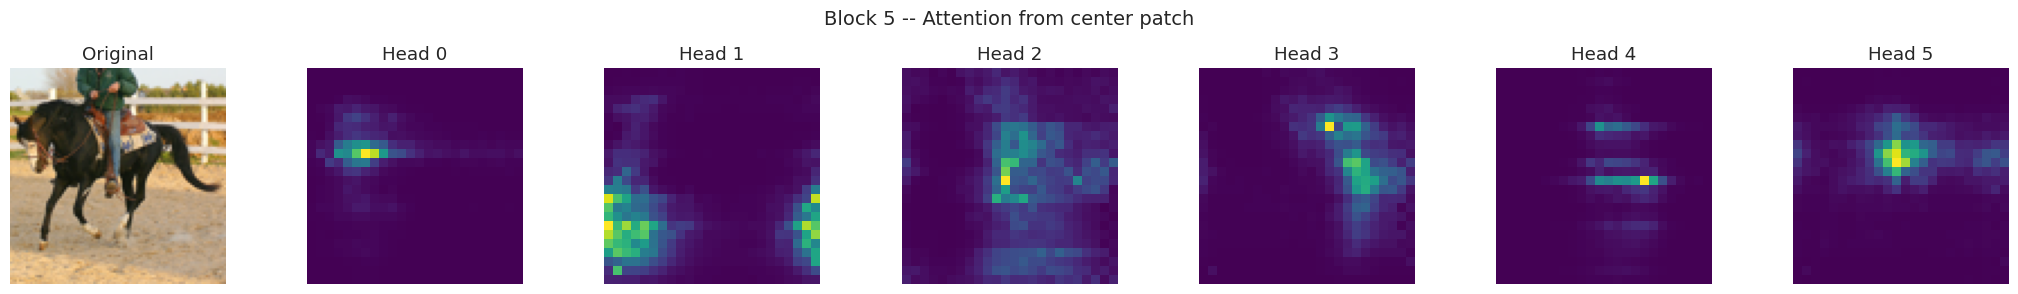

In [10]:
# Visualize attention from the center query patch
# 576 = 24x24 patches (patch_size=4, image=96)
grid_size = model.grid_size  # 24
center = grid_size * (grid_size // 2) + (grid_size // 2)

def denormalize(tensor, mean=STL10_MEAN, std=STL10_STD):
    t = tensor.clone()
    for i, (m, s) in enumerate(zip(mean, std)):
        t[i].mul_(s).add_(m)
    return t.clamp(0, 1)

# Show original image
orig_display = denormalize(sample_img[0].cpu()).permute(1, 2, 0).numpy()

for layer_idx in [0, 2, 5]:
    attn = attn_maps[layer_idx][0]  # (6, 576, 576)
    fig, axes = plt.subplots(1, 7, figsize=(21, 3))
    fig.suptitle(f"Block {layer_idx} -- Attention from center patch", fontsize=14)

    axes[0].imshow(orig_display)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for head in range(6):
        head_attn = attn[head, center].reshape(grid_size, grid_size)
        axes[head + 1].imshow(head_attn.numpy(), cmap="viridis")
        axes[head + 1].set_title(f"Head {head}")
        axes[head + 1].axis("off")

    plt.tight_layout()
    plt.show()

## D. Target Block Masking Visualization

I-JEPA uses contiguous rectangular target blocks (unlike MAE's random masking).
We visualize the context/target split and compare the cosine similarity between
predicted and target representations to see how well the predictor has learned.

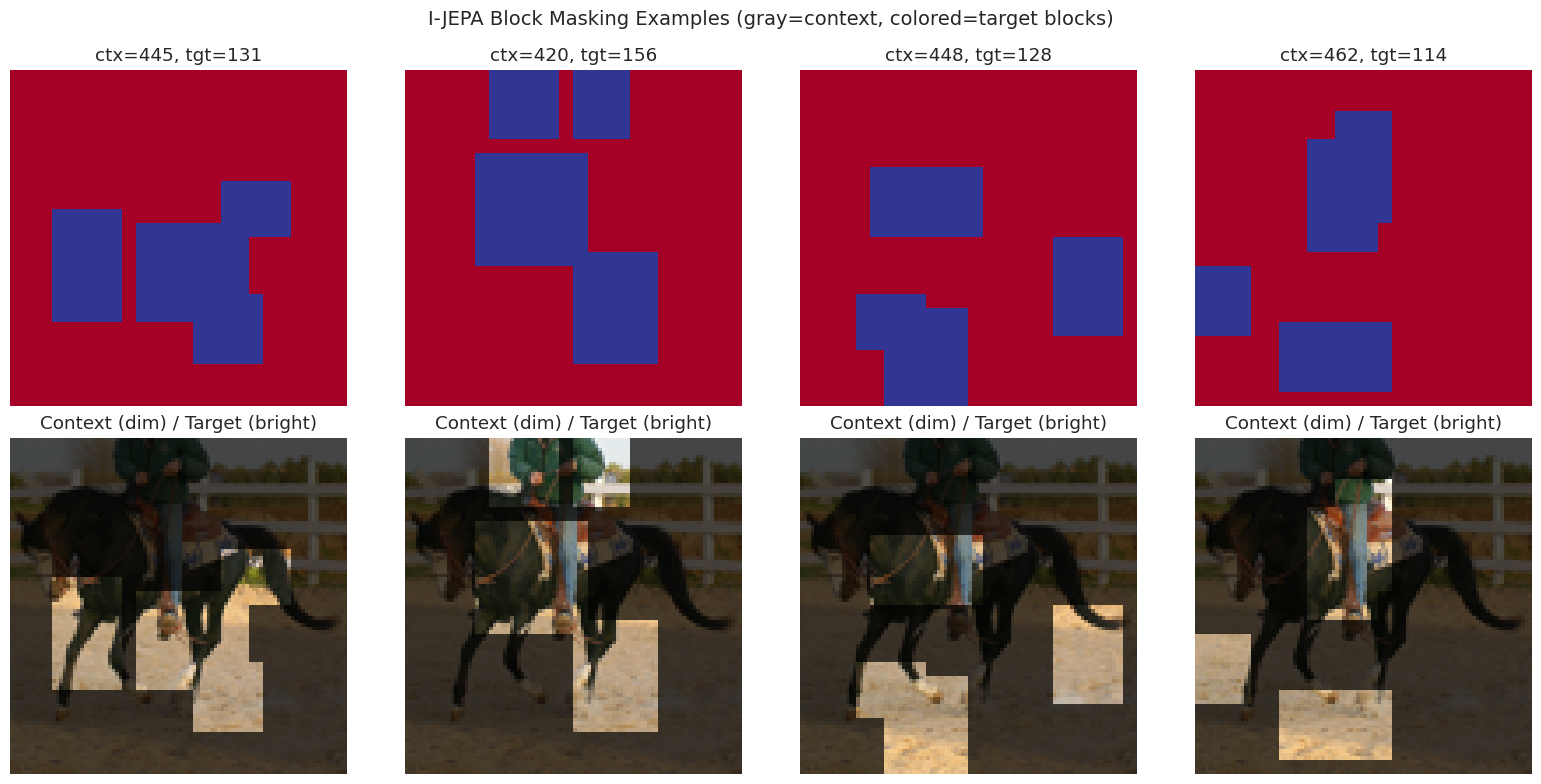

In [11]:
# Generate a few different masks and visualize context vs target regions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("I-JEPA Block Masking Examples (gray=context, colored=target blocks)", fontsize=14)

for col in range(4):
    ids_ctx, ids_tgt, ids_rst = model.generate_masks(1, torch.device("cpu"))
    n_ctx, n_tgt = ids_ctx.shape[1], ids_tgt.shape[1]

    # Build mask image (0=context, 1=target)
    mask_grid = torch.zeros(model.num_patches)
    mask_grid[ids_tgt[0]] = 1.0
    mask_grid = mask_grid.reshape(grid_size, grid_size)

    # Show mask
    axes[0, col].imshow(mask_grid.numpy(), cmap="RdYlBu", vmin=0, vmax=1)
    axes[0, col].set_title(f"ctx={n_ctx}, tgt={n_tgt}")
    axes[0, col].axis("off")

    # Overlay mask on original image
    img_display = orig_display.copy()
    mask_upscaled = mask_grid.numpy().repeat(4, axis=0).repeat(4, axis=1)  # 24x24 -> 96x96
    overlay = img_display.copy()
    overlay[mask_upscaled == 0] *= 0.3  # dim context regions
    axes[1, col].imshow(overlay)
    axes[1, col].set_title("Context (dim) / Target (bright)")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

Target patches per image: 88
Cosine similarity -- mean: 0.9442, std: 0.0297
Cosine similarity -- min: 0.6689, max: 0.9839


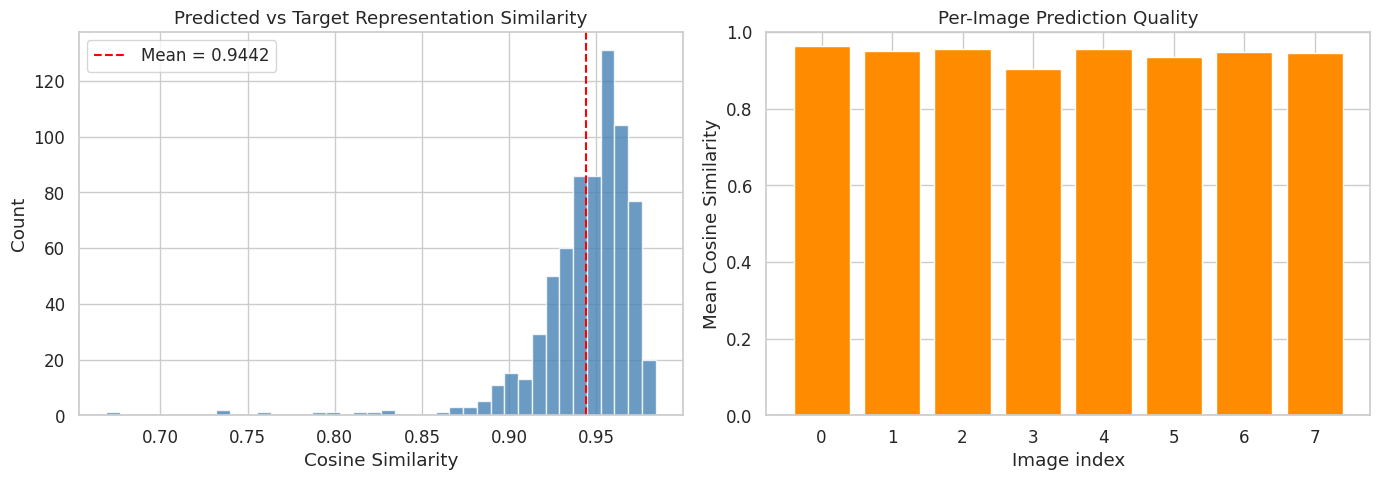

In [12]:
# Run I-JEPA forward on a batch and measure prediction quality
batch = next(iter(loaders["test"]))[0][:8].to(device)

with torch.no_grad():
    ids_ctx, ids_tgt, ids_rst = model.generate_masks(batch.shape[0], batch.device)

    # Context encoder output
    context_tokens = model.encoder.forward_masked(batch, ids_ctx)

    # Target encoder output at target positions
    target_full = model.target_encoder.forward_full(batch)
    D = target_full.shape[-1]
    target_reps = torch.gather(target_full, dim=1, index=ids_tgt.unsqueeze(-1).expand(-1, -1, D))
    target_reps = F.normalize(target_reps, dim=-1)

    # Predictor output
    pred_reps = model.predictor(context_tokens, ids_rst, ids_tgt)
    pred_reps = F.normalize(pred_reps, dim=-1)

    # Per-patch cosine similarity between predictions and targets
    cos_sim = (pred_reps * target_reps).sum(dim=-1)  # (B, n_target)

print(f"Target patches per image: {ids_tgt.shape[1]}")
print(f"Cosine similarity -- mean: {cos_sim.mean():.4f}, std: {cos_sim.std():.4f}")
print(f"Cosine similarity -- min: {cos_sim.min():.4f}, max: {cos_sim.max():.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of per-patch cosine similarities
ax1.hist(cos_sim.cpu().numpy().flatten(), bins=40, color="steelblue", edgecolor="white", alpha=0.8)
ax1.axvline(cos_sim.mean().item(), color="red", linestyle="--", label=f"Mean = {cos_sim.mean():.4f}")
ax1.set_xlabel("Cosine Similarity")
ax1.set_ylabel("Count")
ax1.set_title("Predicted vs Target Representation Similarity")
ax1.legend()

# Per-image mean cosine similarity
per_image_sim = cos_sim.mean(dim=1).cpu().numpy()
ax2.bar(range(len(per_image_sim)), per_image_sim, color="darkorange")
ax2.set_xlabel("Image index")
ax2.set_ylabel("Mean Cosine Similarity")
ax2.set_title("Per-Image Prediction Quality")
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()